# HARGPT Window classification prompt generation and visualization

Cut ACC to the video-aligned subset once, build a window index, then generate a HARGPT-style prompt

Note Mar 27:
1. ship an annotation platform next week best.
2. try the finer gesture classes next week as well?
3. fix my communication
4. verify angle calculation

In [8]:
from pathlib import Path
import pandas as pd

from scripts.video_ltc import ensure_video_timecode_csv, load_record_date_from_metadata_json

PROJECT_ROOT = Path.cwd().resolve()#.parent
OUTPUT_DIR = Path.cwd() / "outputs"
VIDEO_DIR = Path.cwd() / "videos"
OUTPUT_DIR.mkdir(exist_ok=True)
VIDEO_DIR.mkdir(exist_ok=True)

PARTICIPANT_NO = 24
PARTICIPANT_TO_ACCID = {
    1: 81, 2: 64, 3: 72, 4: 78, 5: 74, 6: 85, 7: 73, 8: 87,
    9: 92, 10: 71, 11: 84, 12: 95, 13: 86, 14: 76, 15: 67, 16: 68,
    17: 77, 18: 89, 19: 70, 20: 93, 21: 79, 22: 90, 23: 99, 24: 65,
    25: 75, 26: 80, 27: 66, 28: 82, 29: 83, 30: 94, 31: 91, 32: 88,
}
PARTICIPANT_ID = str(PARTICIPANT_TO_ACCID[PARTICIPANT_NO])
VIDEO_NAME = "GH040226"
VIDEO_FILE = None
VIDEO_START_TIMECODE = None
VIDEO_FPS = None
FORCE_REGENERATE_VIDEO_METADATA = False

TARGET_FS = 50.0
WINDOW_SECONDS = 2.0
STRIDE_SECONDS = 2.0
WINDOW_SIZE = int(TARGET_FS * WINDOW_SECONDS)
STRIDE_SIZE = int(TARGET_FS * STRIDE_SECONDS)

WINDOW_INDEX_IN_VIDEO_SUBSET = 0
PROMPT_WINDOW_COUNT = 400

ACC_FILE = PROJECT_ROOT / "acc_files_cup" / PARTICIPANT_ID / "ACC_0.csv"
VIDEO_FILE, VIDEO_TIMECODE_FILE, VIDEO_METADATA_FILE = ensure_video_timecode_csv(
    video_name=VIDEO_NAME,
    video_file=VIDEO_FILE,
    videos_dir=VIDEO_DIR,
    fallback_timecode=VIDEO_START_TIMECODE,
    fallback_fps=VIDEO_FPS,
    regenerate=FORCE_REGENERATE_VIDEO_METADATA,
)
RECORD_DATE = load_record_date_from_metadata_json(VIDEO_METADATA_FILE)
WINDOW_INDEX_CSV = OUTPUT_DIR / f"hargpt_window_index_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
ACC_VIDEO_CSV = OUTPUT_DIR / f"hargpt_acc_video_subset_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

def parse_time_column(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series.astype(str).str.strip(), errors="coerce")

def load_cup_acc_csv(acc_file: Path) -> pd.DataFrame:
    df = pd.read_csv(acc_file)
    rename_map = {"X": "x", "Y": "y", "Z": "z"}
    df = df.rename(columns=rename_map)
    df = df[["time", "x", "y", "z"]].copy()
    df["time"] = parse_time_column(df["time"])
    df = df.dropna(subset=["time", "x", "y", "z"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    return df

def resample_acc(df: pd.DataFrame, target_fs: float) -> pd.DataFrame:
    freq_ms = int(round(1000.0 / target_fs))
    rule = f"{freq_ms}ms"
    return (
        df.set_index("time")[["x", "y", "z"]]
        .resample(rule)
        .mean()
        .interpolate(method="time")
        .dropna()
        .reset_index()
    )

def load_video_range(video_timecode_file: Path, record_date):
    vid = pd.read_csv(video_timecode_file)
    vid["tc_hms"] = vid["tc_str"].astype(str).str.slice(0, 8)
    vid["video_datetime"] = pd.to_datetime(
        record_date.strftime("%Y-%m-%d") + " " + vid["tc_hms"],
        errors="coerce"
    )
    vid = vid.dropna(subset=["video_datetime"]).sort_values("video_datetime").reset_index(drop=True)
    return vid["video_datetime"].iloc[0], vid["video_datetime"].iloc[-1]

def split_windows(df: pd.DataFrame, window_size: int, stride_size: int) -> pd.DataFrame:
    rows = []
    if len(df) < window_size:
        return pd.DataFrame(rows)
    for start in range(0, len(df) - window_size + 1, stride_size):
        end = start + window_size
        window_df = df.iloc[start:end].copy().reset_index(drop=True)
        rows.append({
            "window_id": len(rows),
            "start_idx_in_video_subset": int(start),
            "end_idx_in_video_subset": int(end - 1),
            "start_time": window_df.loc[0, "time"],
            "end_time": window_df.loc[len(window_df) - 1, "time"],
        })
    return pd.DataFrame(rows)

raw_acc = load_cup_acc_csv(ACC_FILE)
acc_resampled = resample_acc(raw_acc, TARGET_FS)
video_start, video_end = load_video_range(VIDEO_TIMECODE_FILE, RECORD_DATE)
acc_video = acc_resampled[(acc_resampled["time"] >= video_start) & (acc_resampled["time"] <= video_end)].copy().reset_index(drop=True)
if len(acc_video) < WINDOW_SIZE:
    raise ValueError("Video subset is shorter than one analysis window.")

acc_video.to_csv(ACC_VIDEO_CSV, index=False)
window_index_df = split_windows(acc_video, WINDOW_SIZE, STRIDE_SIZE)
window_index_df.to_csv(WINDOW_INDEX_CSV, index=False)

print(f"Video file: {VIDEO_FILE}")
print(f"Video timecode CSV: {VIDEO_TIMECODE_FILE}")
print(f"Video metadata JSON: {VIDEO_METADATA_FILE}")
print(f"ACC video subset saved to: {ACC_VIDEO_CSV}")
print(f"Window index saved to: {WINDOW_INDEX_CSV}")
print(f"Video range: {video_start} -> {video_end}")
print(f"Video-subset windows: {len(window_index_df)}")
window_index_df.head()


Video file: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\videos\GH040226.mp4
Video timecode CSV: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\videos\video_timecode_1HzGH040226.csv
Video metadata JSON: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\videos\video_metadata_GH040226.json
ACC video subset saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\outputs\hargpt_acc_video_subset_65_GH040226.csv
Window index saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\outputs\hargpt_window_index_65_GH040226.csv
Video range: 2025-07-17 13:57:00 -> 2025-07-17 14:08:47
Video-subset windows: 353


,window_id,start_idx_in_video_subset,end_idx_in_video_subset,start_time,end_time
0,0,0,99,2025-07-17 13:57:00,2025-07-17 13:57:01.980
1,1,100,199,2025-07-17 13:57:02,2025-07-17 13:57:03.980
2,2,200,299,2025-07-17 13:57:04,2025-07-17 13:57:05.980
3,3,300,399,2025-07-17 13:57:06,2025-07-17 13:57:07.980
4,4,400,499,2025-07-17 13:57:08,2025-07-17 13:57:09.980


In [9]:
# Process weak labels
import json
import numpy as np

WEAK_LABEL_INPUT = PROJECT_ROOT / "weak_label" / f"{PARTICIPANT_NO}.json"
WEAK_LABEL_OUTPUT = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Drinking": 2,
    "Toasting": 3,
    "Nodding": 4,
}
label_priority = {
    "Still": 0,
    "Nodding": 1,
    "Gesture": 2,
    "Toasting": 3,
    "Drinking": 4,
}
category_aliases = {
    "still": "Still",
    "gesture": "Gesture",
    "drink": "Drinking",
    "drinking": "Drinking",
    "toast": "Toasting",
    "toasting": "Toasting",
    "nodding": "Nodding",
}

if not WEAK_LABEL_INPUT.exists():
    raise FileNotFoundError(f"Weak label file not found: {WEAK_LABEL_INPUT}")

weak_segments = json.loads(WEAK_LABEL_INPUT.read_text(encoding="utf-8"))
weak_df = pd.DataFrame(weak_segments)

required_cols = {"start", "end", "category"}
missing_cols = required_cols - set(weak_df.columns)
if missing_cols:
    raise ValueError(f"Weak label JSON missing required fields: {sorted(missing_cols)}")

weak_df = weak_df.copy()
weak_df["start"] = pd.to_numeric(weak_df["start"], errors="coerce")
weak_df["end"] = pd.to_numeric(weak_df["end"], errors="coerce")
weak_df["category"] = weak_df["category"].astype(str).str.strip()
weak_df["category"] = weak_df["category"].map(lambda value: category_aliases.get(str(value).strip().lower(), str(value).strip()))
weak_df = weak_df.dropna(subset=["start", "end", "category"]).sort_values(["start", "end"]).reset_index(drop=True)

invalid_segments = weak_df[weak_df["end"] < weak_df["start"]].copy()
if not invalid_segments.empty:
    raise ValueError("Weak label contains segments with end < start.")

unknown_categories = sorted(set(weak_df["category"]) - set(label_to_state))
if unknown_categories:
    raise ValueError(f"Unknown weak label categories: {unknown_categories}")

weak_df["abs_start"] = video_start + pd.to_timedelta(weak_df["start"], unit="s")
weak_df["abs_end"] = video_start + pd.to_timedelta(weak_df["end"], unit="s")
weak_df["clipped_start"] = weak_df["abs_start"].clip(lower=video_start, upper=video_end)
weak_df["clipped_end"] = weak_df["abs_end"].clip(lower=video_start, upper=video_end)
weak_df = weak_df[weak_df["clipped_end"] >= weak_df["clipped_start"]].reset_index(drop=True)

acc_weak = acc_video.copy()
acc_weak["time"] = pd.to_datetime(acc_weak["time"])
acc_weak["state"] = label_to_state["Still"]
acc_weak["weak_label"] = "Still"
priority_buffer = np.zeros(len(acc_weak), dtype=int)

for row in weak_df.itertuples(index=False):
    priority = label_priority[row.category]
    mask = (acc_weak["time"] >= row.clipped_start) & (acc_weak["time"] <= row.clipped_end)
    if not mask.any():
        continue
    mask_np = mask.to_numpy()
    update_mask = mask_np & (priority >= priority_buffer)
    if not update_mask.any():
        continue
    priority_buffer[update_mask] = priority
    acc_weak.loc[update_mask, "state"] = label_to_state[row.category]
    acc_weak.loc[update_mask, "weak_label"] = row.category

acc_weak["video_name"] = VIDEO_NAME
acc_weak = acc_weak[["time", "x", "y", "z", "state", "weak_label", "video_name"]]
acc_weak.to_csv(WEAK_LABEL_OUTPUT, index=False)

print(f"Weak label input: {WEAK_LABEL_INPUT}")
print(f"Weak label output: {WEAK_LABEL_OUTPUT}")
print(f"Video range: {video_start} -> {video_end}")
print(f"ACC rows labeled: {len(acc_weak)}")
print(acc_weak["weak_label"].value_counts().sort_index())
acc_weak.head()


Weak label input: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\weak_label\24.json
Weak label output: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\weak_label\weak_labels_65_GH040226.csv
Video range: 2025-07-17 13:57:00 -> 2025-07-17 14:08:47
ACC rows labeled: 35351
weak_label
Drinking      553
Gesture     10223
Nodding      3939
Still       20544
Toasting       92
Name: count, dtype: int64


,time,x,y,z,state,weak_label,video_name
0,2025-07-17 13:57:00.000,-0.079102,-0.051270,-1.019043,0,Still,GH040226
1,2025-07-17 13:57:00.020,-0.080811,-0.041260,-1.022949,0,Still,GH040226
2,2025-07-17 13:57:00.040,-0.092285,-0.051758,-1.022461,0,Still,GH040226
3,2025-07-17 13:57:00.060,-0.084961,-0.048340,-1.016113,0,Still,GH040226
4,2025-07-17 13:57:00.080,-0.084961,-0.043945,-1.006836,0,Still,GH040226


In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

seq = mpl.color_sequences["tab10"]

# Set the plot style and background color to white
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams["savefig.transparent"] = False

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])

available_window_count = max(0, len(window_index_df) - WINDOW_INDEX_IN_VIDEO_SUBSET)
actual_prompt_window_count = min(PROMPT_WINDOW_COUNT, available_window_count)
if actual_prompt_window_count <= 0:
    raise ValueError(f"Start window {WINDOW_INDEX_IN_VIDEO_SUBSET} is outside the available range 0..{max(len(window_index_df) - 1, 0)}.")

selected_meta = window_index_df.iloc[
    WINDOW_INDEX_IN_VIDEO_SUBSET: WINDOW_INDEX_IN_VIDEO_SUBSET + actual_prompt_window_count
].copy()
SEMANTIC_CLASSES = [
    "Still",
    "Gesture",
    "Drinking",
    "Toasting",
    "Nodding",
]

def tilt_angle_deg(gx, gy, gz, ref_slice):
    gref = np.array([gx[ref_slice].mean(), gy[ref_slice].mean(), gz[ref_slice].mean()], dtype=float)
    gref_n = np.linalg.norm(gref) + 1e-8

    g = np.stack([gx, gy, gz], axis=1)
    g_n = np.linalg.norm(g, axis=1) + 1e-8

    cosv = (g @ gref) / (g_n * gref_n)
    cosv = np.clip(cosv, -1.0, 1.0)
    return np.degrees(np.arccos(cosv))

acc_full = resample_acc(load_cup_acc_csv(ACC_FILE), TARGET_FS)
tilt_ref_samples = min(int(2 * TARGET_FS), len(acc_full))
if tilt_ref_samples == 0:
    raise ValueError("ACC file is empty; cannot compute tilt reference.")
tilt_ref_slice = slice(0, tilt_ref_samples)
full_tilt = tilt_angle_deg(
    acc_full["x"].to_numpy(dtype=float),
    acc_full["y"].to_numpy(dtype=float),
    acc_full["z"].to_numpy(dtype=float),
    ref_slice=tilt_ref_slice,
)
video_start_in_full = int(acc_full["time"].searchsorted(acc_video.loc[0, "time"]))

window_payloads = []
for row in selected_meta.itertuples(index=False):
    start_idx = int(row.start_idx_in_video_subset)
    end_idx = int(row.end_idx_in_video_subset) + 1
    window_df = acc_video.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    full_start_idx = video_start_in_full + start_idx
    full_end_idx = video_start_in_full + end_idx
    tilt = full_tilt[full_start_idx:full_end_idx]
    window_payloads.append({
        "window_id": int(row.window_id),
        "raw_xyz_sequence": {
            "x": [round(float(v), 6) for v in window_df["x"]],
            "y": [round(float(v), 6) for v in window_df["y"]],
            "z": [round(float(v), 6) for v in window_df["z"]],
        },
        "tilt_angle_deg_sequence": [round(float(v), 6) for v in tilt],
    })
# maybe learn the classes?
# prove the accuracy of the model?
# more classes for finer grain gestures?
def window_payloads_xyz_only(window_payloads):
    return [
        {
            "window_id": window["window_id"],
            "raw_xyz_sequence": window["raw_xyz_sequence"],
        }
        for window in window_payloads
    ]



def summarize_sequence(values):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            "mean": None,
            "max": None,
            "min": None,
            "q1": None,
            "q3": None,
            "std": None,
            "median": None,
        }
    return {
        "mean": round(float(np.mean(arr)), 6),
        "max": round(float(np.max(arr)), 6),
        "min": round(float(np.min(arr)), 6),
        "q1": round(float(np.percentile(arr, 25)), 6),
        "q3": round(float(np.percentile(arr, 75)), 6),
        "std": round(float(np.std(arr, ddof=0)), 6),
        "median": round(float(np.median(arr)), 6),
    }


def three_way_slices(length):
    edges = np.linspace(0, length, 4, dtype=int)
    return {
        "start": slice(edges[0], edges[1]),
        "mid": slice(edges[1], edges[2]),
        "end": slice(edges[2], edges[3]),
    }


def window_payloads_xyz_rag_tilt(window_payloads):
    rag_payloads = []
    for window in window_payloads:
        x_values = window["raw_xyz_sequence"]["x"]
        y_values = window["raw_xyz_sequence"]["y"]
        z_values = window["raw_xyz_sequence"]["z"]
        tilt_values = window["tilt_angle_deg_sequence"]
        segment_slices = {"full": slice(0, len(tilt_values))}
        segment_slices.update(three_way_slices(len(tilt_values)))

        segment_statistics = {}
        for segment_name, segment_slice in segment_slices.items():
            segment_statistics[segment_name] = {
                "x": summarize_sequence(x_values[segment_slice]),
                "y": summarize_sequence(y_values[segment_slice]),
                "z": summarize_sequence(z_values[segment_slice]),
                "tilt": summarize_sequence(tilt_values[segment_slice]),
            }

        rag_payloads.append({
            "window_id": window["window_id"],
            "raw_xyz_sequence": window["raw_xyz_sequence"],
            "tilt_angle_deg_sequence": window["tilt_angle_deg_sequence"],
            "segment_statistics": segment_statistics,
        })
    return rag_payloads


def build_original_hargpt_prompt(window_payloads, include_tilt=True):
    has_segment_statistics = bool(window_payloads) and "segment_statistics" in window_payloads[0]
    sensor_description = (
        "For each window, the three-axis accelerations, derived tilt angle, and RAG-style segment summaries for full/start/mid/end are given in the accompanying JSON input."
        if include_tilt and has_segment_statistics
        else "For each window, the three-axis accelerations and derived tilt angle are given in the accompanying JSON input."
        if include_tilt
        else "For each window, only the three-axis accelerations are given in the accompanying JSON input."
    )
    input_fields = "- window_id: unique window identifier\n- raw_xyz_sequence: x-axis, y-axis, and z-axis acceleration sequences"
    if include_tilt:
        input_fields += "\n- tilt_angle_deg_sequence: derived tilt angle sequence in degrees"
    if has_segment_statistics:
        input_fields += "\n- segment_statistics: statistical summaries for full/start/mid/end, each containing x/y/z/tilt mean, max, min, q1, q3, std, and median"

    return f'''You are an expert of IMU-based human activity analysis.

Question: The IMU data is collected from a smart cup held by the user with a sampling rate of 50 Hz. The IMU data is given in the smart-cup IMU coordinate frame. {sensor_description}

Input JSON fields:
{input_fields}

The person's action belongs to one of the following categories:
- Still
- Gesture
- Drinking
- Toasting
- Nodding

Could you please tell me what action the person was doing based on the given
information and IMU readings?

Within each window, identify one or more temporal segments.
For each segment, return:
- start_time
- end_time
- predicted_class
- reason

Use start_time and end_time in seconds relative to the beginning of the current window.

Return exactly one JSON array with one object per window:
[{{"window_id":0,"segments":[{{"start_time":0.00,"end_time":0.42,"predicted_class":"<class>","reason":"<brief explanation>"}}]}}]

Use only the category labels listed above. Return in JSON file format.'''


def build_hargpt_prompt_window_localization(window_payloads, include_tilt=True):
    has_segment_statistics = bool(window_payloads) and "segment_statistics" in window_payloads[0]
    input_fields = "- window_id: unique window identifier\n- raw_xyz_sequence: x-axis, y-axis, and z-axis acceleration sequences"
    if include_tilt:
        input_fields += "\n- tilt_angle_deg_sequence: derived tilt angle sequence in degrees"
    if has_segment_statistics:
        input_fields += "\n- segment_statistics: statistical summaries for full/start/mid/end, each containing x/y/z/tilt mean, max, min, q1, q3, std, and median"

    return f'''You are an expert of IMU-based human activity analysis.

I will give you raw motion sensor data from a smart cup.
The device contains an accelerometer only.
The device moves with the cup rather than being worn on the body.
The sampling rate is 50 Hz.

Your task is to localize the activities within each window from the raw sensor sequences.

Input JSON fields:
{input_fields}

Candidate classes (use these exact labels):
- Still
- Gesture
- Toasting
- Drinking
- Nodding

Please analyze the raw accelerometer data step by step.

Important distinction between Still and Nodding:
- Still does NOT mean simply low overall variance.
- Still should be used only when the signal shows no meaningful structured micro-movement and no nod-like localized event.
- Nodding can be subtle in a smart-cup accelerometer and may occur inside an otherwise still window.
- Do NOT require large amplitude or large tilt for Nodding.
- A Nodding event is typically a brief localized micro-event, often about 0.2 to 1.2 s, with a small dip-and-return, rise-and-return, or 1 to 3 short oscillatory pulses, followed by recovery toward the previous baseline.
- Judge Nodding by local structure relative to the nearby baseline, not only by absolute motion magnitude.

Decision order for each window:
1. First look for localized events, especially subtle Nodding segments, even if the whole window looks mostly quiet.
2. Only after checking for localized Nodding, decide whether the remaining parts are Still.
3. Prefer "Still + short Nodding segment" over labeling the entire window as Still when a plausible nod-like micro-pattern is present.
4. Use Gesture for broader non-drinking motion that is clearly structured but not better explained as Still, Nodding, Toasting, or Drinking.

Use these cues:
- overall motion intensity
- variability of acceleration
- relationships between x, y, and z axes
- tilt angle
- local departures from baseline
- brief oscillatory or dip-return structure
- recovery back toward baseline

Nodding positive cues:
- brief localized event within a mostly stable window
- small but structured deviation from baseline
- dip-and-return or short oscillatory pattern
- recovery toward the previous baseline
- subtle coordinated variation across axes or tilt

Nodding negative cues:
- completely flat signal with no localized deviation
- isolated noisy spike with no structure
- long broad movement better explained as Gesture or Drinking
- large monotonic tilt increase toward the mouth
- sustained high-angle hold
Do not default to a single full-window Still segment.
If the window is mostly quiet, explicitly check whether a short Nodding segment should be carved out from the quiet background.

Gesture means broader non-drinking hand/cup motion that is not better explained as Toasting, Drinking, or Nodding.
For drink consider only large angles (>40).
Drinking may contain a raise-to-mouth phase, an at-mouth or drinking-hold phase, and a return-from-mouth phase, but all of these should be labeled as Drinking.
Use those three drinking sub-phases only as reasoning cues for temporal structure, not as output labels.

Use temporal continuity across adjacent windows if it helps, but output the result separately for each window.

Within each window, identify one or more temporal segments.
For each segment, return:
- start_time
- end_time
- predicted_class
- reason

Use start_time and end_time in seconds relative to the beginning of the current window.

Return exactly one JSON array with one object per window:
[{{"window_id":0,"segments":[{{"start_time":0.00,"end_time":0.42,"predicted_class":"<class>","reason":"<brief explanation>"}}]}}]

Return in JSON file format.
Do not use code script to extract statistical values and still process the data directly.
'''


actual_window_end = int(selected_meta["window_id"].iloc[-1])
batch_name = f"hargpt_windows_{WINDOW_INDEX_IN_VIDEO_SUBSET}_to_{actual_window_end}_{PARTICIPANT_ID}_{VIDEO_NAME}"
batch_dir = OUTPUT_DIR / batch_name
batch_dir.mkdir(exist_ok=True)

feature_sets = {
    "xyz_only": {
        "payloads": window_payloads_xyz_only(window_payloads),
        "include_tilt": False,
    },
    "xyz_tilt": {
        "payloads": window_payloads,
        "include_tilt": True,
    },
    "xyz_RAG_tilt": {
        "payloads": window_payloads_xyz_rag_tilt(window_payloads),
        "include_tilt": True,
    },
}

prompt_styles = {
    "original HARGPT": {
        "builder": build_original_hargpt_prompt,
        "prompt_file_suffix": "prompt_window_classification",
    },
    "Rule_based_localization": {
        "builder": build_hargpt_prompt_window_localization,
        "prompt_file_suffix": "prompt_window_localization",
    },
}

generated_files = []
for prompt_style, prompt_config in prompt_styles.items():
    style_dir = batch_dir / prompt_style
    for feature_set, feature_config in feature_sets.items():
        data_dir = style_dir / "window_data" / feature_set
        prompt_dir = style_dir / "prompts" / feature_set
        prediction_dir = style_dir / "predictions" / feature_set
        data_dir.mkdir(parents=True, exist_ok=True)
        prompt_dir.mkdir(parents=True, exist_ok=True)
        prediction_dir.mkdir(parents=True, exist_ok=True)

        dataset_path = data_dir / f"{batch_name}_{feature_set}.json"
        prompt_path = prompt_dir / f"{batch_name}_{prompt_config['prompt_file_suffix']}_{feature_set}.txt"

        payloads = feature_config["payloads"]
        include_tilt = feature_config["include_tilt"]
        dataset_path.write_text(json.dumps(payloads, indent=2, ensure_ascii=False), encoding="utf-8")
        prompt_path.write_text(prompt_config["builder"](payloads, include_tilt=include_tilt), encoding="utf-8")
        generated_files.extend([dataset_path, prompt_path])


def prediction_dir_for(prompt_style: str, feature_set: str) -> Path:
    if prompt_style not in prompt_styles:
        raise ValueError(f"Unknown prompt style: {prompt_style}. Use one of {list(prompt_styles)}")
    if feature_set not in feature_sets:
        raise ValueError(f"Unknown feature set: {feature_set}. Use one of {list(feature_sets)}")
    path = batch_dir / prompt_style / "predictions" / feature_set
    path.mkdir(parents=True, exist_ok=True)
    return path


def prediction_result_path(prompt_style: str, feature_set: str, model_name: str = "chatgpt") -> Path:
    safe_model_name = str(model_name).strip().lower().replace(" ", "_")
    return prediction_dir_for(prompt_style, feature_set) / f"{batch_name}_predictions_local_{safe_model_name}_{feature_set}.json"


def iter_prediction_jsons(batch_dir: Path):
    for prompt_style in prompt_styles:
        for feature_set in feature_sets:
            prediction_dir = batch_dir / prompt_style / "predictions" / feature_set
            if not prediction_dir.exists():
                continue
            for result_path in sorted(prediction_dir.glob("*.json")):
                yield prompt_style, feature_set, result_path


def resolve_chatgpt_result_path(batch_dir: Path, participant_id: str) -> Path:
    matches = []
    for _prompt_style, _feature_set, result_path in iter_prediction_jsons(batch_dir):
        lower_name = result_path.name.lower()
        if "chatgpt" in lower_name or f"{participant_id}" in lower_name:
            matches.append(result_path)

    matches = sorted(matches, key=lambda path: path.stat().st_mtime, reverse=True)
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"No ChatGPT result JSON found under {batch_dir}/*/predictions/*/."
    )

print(f"Prompt-style batch folder: {batch_dir}")
for generated_file in generated_files:
    print(f"Generated: {generated_file}")
# selected_meta


Saved weak-label overlay plot to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\outputs\weak_labels_overlay_65_GH040226.png


WindowsPath('G:/TUD_CESE/OneDrive - Delft University of Technology/Smart Cup/relativeWorks/hargpt_dir/outputs/weak_labels_overlay_65_GH040226.png')

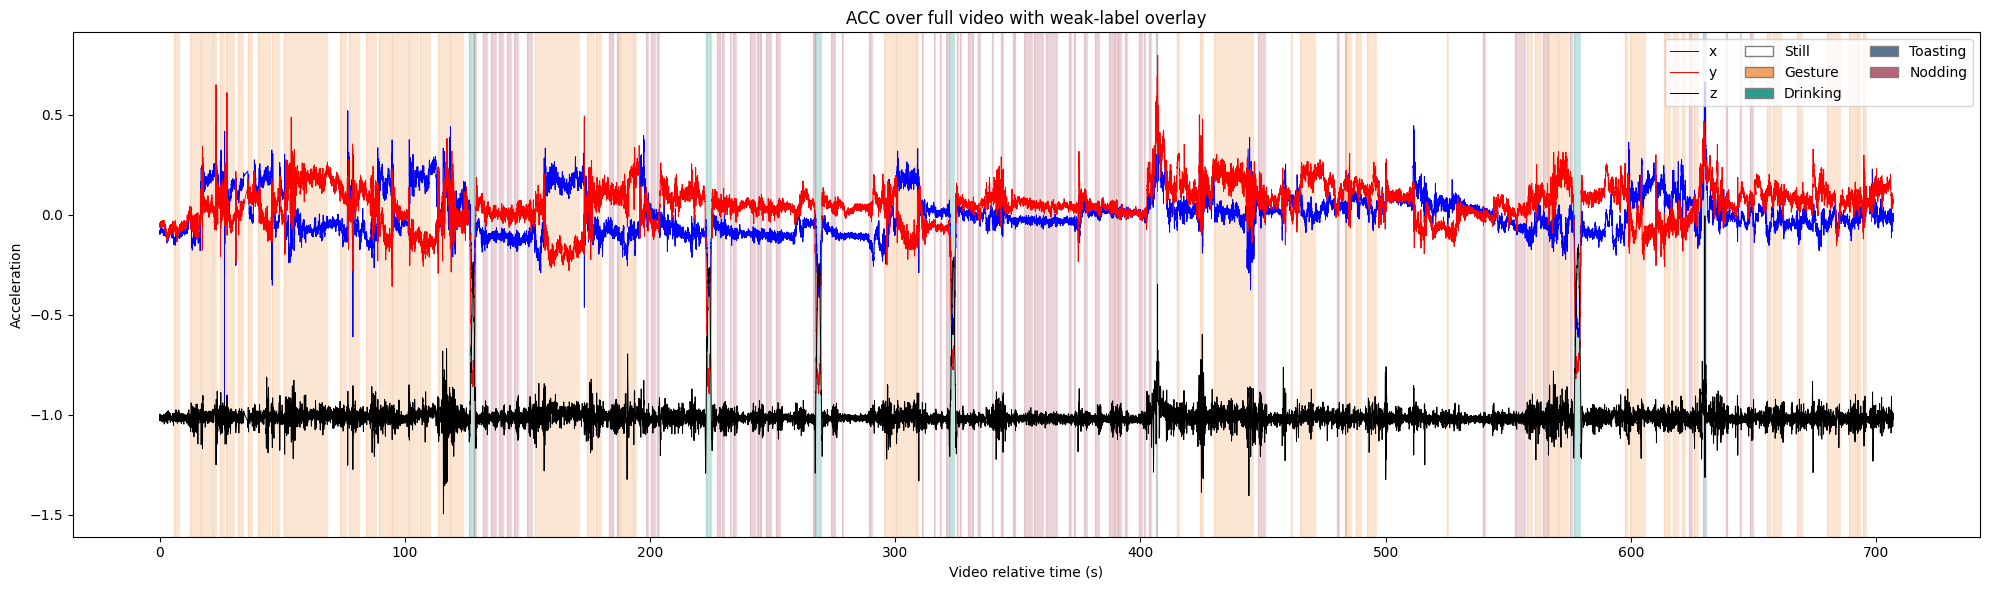

In [12]:
# Plot weak labels on the full video-aligned ACC subset
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

WEAK_LABEL_FILE = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
WEAK_LABEL_OVERLAY_PNG = OUTPUT_DIR / f"weak_labels_overlay_{PARTICIPANT_ID}_{VIDEO_NAME}.png"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Drinking": 2,
    "Toasting": 3,
    "Nodding": 4,
}
state_to_name = {
    0: "Still",
    1: "Gesture",
    2: "Drinking",
    3: "Toasting",
    4: "Nodding",
}
state_colors = {
    0: "white",
    1: "#f4a261",
    2: "#2a9d8f",
    3: "#577590",
    4: "#b56576",
}

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams["savefig.transparent"] = False

acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
acc_video["time_rel_s"] = (acc_video["time"] - video_start).dt.total_seconds()

weak_df = pd.read_csv(WEAK_LABEL_FILE)
weak_df["time"] = pd.to_datetime(weak_df["time"])
weak_df = weak_df.sort_values("time").reset_index(drop=True)
weak_df["time_rel_s"] = (weak_df["time"] - video_start).dt.total_seconds()

weak_runs = []
if not weak_df.empty:
    start_idx = 0
    for i in range(1, len(weak_df) + 1):
        if i == len(weak_df) or weak_df.loc[i, "weak_label"] != weak_df.loc[i - 1, "weak_label"]:
            weak_runs.append((
                weak_df.loc[start_idx, "time_rel_s"],
                weak_df.loc[i - 1, "time_rel_s"],
                weak_df.loc[i - 1, "weak_label"],
            ))
            start_idx = i

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for start_time, end_time, weak_label in weak_runs:
    weak_state = label_to_state.get(str(weak_label), 0)
    ax.axvspan(start_time, end_time, color=state_colors[int(weak_state)], alpha=0.28)

ax.plot(acc_video["time_rel_s"], acc_video["x"], label="x", color="blue", linewidth=0.7)
ax.plot(acc_video["time_rel_s"], acc_video["y"], label="y", color="red", linewidth=0.7)
ax.plot(acc_video["time_rel_s"], acc_video["z"], label="z", color="black", linewidth=0.7)
ax.set_title("ACC over full video with weak-label overlay")
ax.set_ylabel("Acceleration")
ax.set_xlabel("Video relative time (s)")

legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2, 3, 4]]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(line_handles + legend_handles, line_labels + [state_to_name[s] for s in [0, 1, 2, 3, 4]], loc="upper right", ncol=3)

fig.tight_layout()
fig.savefig(WEAK_LABEL_OVERLAY_PNG, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
print(f"Saved weak-label overlay plot to: {WEAK_LABEL_OVERLAY_PNG}")
WEAK_LABEL_OVERLAY_PNG


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

MANUAL_LABEL_FILE = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Drinking": 2,
    "Toasting": 3,
    "Nodding": 4,
}
state_to_name = {
    0: "Still",
    1: "Gesture",
    2: "Drinking",
    3: "Toasting",
    4: "Nodding",
}
state_colors = {
    0: "white",
    1: "#f4a261",
    2: "#2a9d8f",
    3: "#577590",
    4: "#b56576",
}
label_priority = {
    "Still": 0,
    "Nodding": 1,
    "Gesture": 2,
    "Toasting": 3,
    "Drinking": 4,
}

fine_class_to_coarse_label = {
    "still": "Still",
    "gesture": "Gesture",
    "gesture stroke": "Gesture",
    "gesture phrase": "Gesture",
    "hand switch": "Gesture",
    "drinking": "Drinking",
    "drink": "Drinking",
    "raise to mouth": "Drinking",
    "at mouth or drinking hold": "Drinking",
    "return from mouth": "Drinking",
    "raise to lips": "Drinking",
    "return from lips": "Drinking",
    "toasting": "Toasting",
    "toast": "Toasting",
    "nodding": "Nodding",
    "head nod": "Nodding",
}


def normalize_label(value):
    if pd.isna(value):
        return pd.NA
    return str(value).strip().lower()


def map_prediction_to_coarse_label(value):
    normalized = normalize_label(value)
    if pd.isna(normalized):
        return pd.NA
    if normalized in fine_class_to_coarse_label:
        return fine_class_to_coarse_label[normalized]
    title_label = str(value).strip().title()
    if title_label in label_to_state:
        return title_label
    return pd.NA


def prediction_json_candidates():
    if "iter_prediction_jsons" in globals():
        yield from iter_prediction_jsons(batch_dir)
        return

    for result_path in sorted(batch_dir.glob("*/predictions/*/*.json")):
        prompt_style = result_path.parents[2].name
        feature_set = result_path.parent.name
        yield prompt_style, feature_set, result_path


def prediction_df_from_json(result_path):
    predictions = json.loads(result_path.read_text(encoding="utf-8"))
    if not isinstance(predictions, list):
        raise ValueError("Prediction JSON must be a JSON array.")

    pred_df = pd.DataFrame(predictions)
    if pred_df.empty:
        raise ValueError("Prediction JSON is empty.")

    if "segments" in pred_df.columns and "predicted_class" not in pred_df.columns:
        pred_df = pred_df.explode("segments", ignore_index=True)
        seg_df = pd.json_normalize(pred_df["segments"]).rename(columns={
            "start_time": "segment_start_s",
            "end_time": "segment_end_s",
        })
        pred_df = pd.concat(
            [pred_df.drop(columns=["segments"]).reset_index(drop=True), seg_df.reset_index(drop=True)],
            axis=1,
        )
        required_cols = {"window_id", "segment_start_s", "segment_end_s", "predicted_class"}
        missing_cols = required_cols - set(pred_df.columns)
        if missing_cols:
            raise ValueError(f"Prediction JSON missing required fields: {sorted(missing_cols)}")
        pred_df = pred_df.merge(
            window_index_df[["window_id", "start_time", "end_time"]].rename(columns={
                "start_time": "window_start_time",
                "end_time": "window_end_time",
            }),
            on="window_id",
            how="left",
        )
        pred_df["start_time"] = pred_df["window_start_time"] + pd.to_timedelta(pred_df["segment_start_s"], unit="s")
        pred_df["end_time"] = pred_df["window_start_time"] + pd.to_timedelta(pred_df["segment_end_s"], unit="s")
        pred_df["start_time"] = pred_df[["start_time", "window_start_time"]].max(axis=1)
        pred_df["end_time"] = pred_df[["end_time", "window_end_time"]].min(axis=1)
    else:
        required_cols = {"window_id", "predicted_class"}
        missing_cols = required_cols - set(pred_df.columns)
        if missing_cols:
            raise ValueError(f"Prediction JSON missing required fields: {sorted(missing_cols)}")
        pred_df = pred_df.merge(window_index_df[["window_id", "start_time", "end_time"]], on="window_id", how="left")

    pred_df["coarse_label"] = pred_df["predicted_class"].map(map_prediction_to_coarse_label)
    pred_df["predicted_state"] = pred_df["coarse_label"].map(label_to_state)
    pred_df = pred_df.sort_values(["window_id", "start_time", "end_time"]).reset_index(drop=True)

    invalid_rows = pred_df[
        pred_df[["coarse_label", "predicted_state", "start_time", "end_time"]].isna().any(axis=1)
    ].copy()
    if not invalid_rows.empty:
        print("Invalid prediction rows detected:")
        display(invalid_rows[["window_id", "predicted_class", "coarse_label", "predicted_state", "start_time", "end_time"]])
        pred_df = pred_df.drop(index=invalid_rows.index).reset_index(drop=True)

    pred_df = pred_df[pred_df["end_time"] >= pred_df["start_time"]].reset_index(drop=True)
    if pred_df.empty:
        raise ValueError("No valid prediction intervals available after validation.")

    pred_df["predicted_state"] = pred_df["predicted_state"].astype(int)
    return pred_df


def plot_prediction_result(prompt_style, feature_set, result_path):
    pred_df = prediction_df_from_json(result_path)
    output_dir = result_path.parent / result_path.stem
    output_dir.mkdir(parents=True, exist_ok=True)

    compare_png = output_dir / "comparison_vs_manual_labels.png"
    confusion_csv = output_dir / "confusion_counts.csv"

    plot_start = pred_df["start_time"].min()
    plot_end = pred_df["end_time"].max()
    plot_origin = plot_start

    acc_plot = acc_video[(acc_video["time"] >= plot_start) & (acc_video["time"] <= plot_end)].copy().reset_index(drop=True)
    manual_plot = manual_df[(manual_df["time"] >= plot_start) & (manual_df["time"] <= plot_end)].copy().reset_index(drop=True)
    if manual_plot.empty:
        raise ValueError("No manual labels overlap with the selected prediction range.")

    manual_plot = manual_plot.sort_values("time").reset_index(drop=True)
    manual_plot = manual_plot.rename(columns={"state": "manual_state", "weak_label": "manual_label"})
    manual_plot["manual_state"] = manual_plot["manual_state"].astype(int)

    acc_pred = manual_plot[["time", "manual_state", "manual_label"]].copy()
    acc_pred["predicted_state"] = label_to_state["Still"]
    acc_pred["predicted_label"] = "Still"
    priority_buffer = pd.Series(label_priority["Still"], index=acc_pred.index, dtype=int)

    for row in pred_df.itertuples(index=False):
        coarse_label = row.coarse_label
        priority = label_priority[coarse_label]
        mask = (acc_pred["time"] >= row.start_time) & (acc_pred["time"] <= row.end_time)
        if not mask.any():
            continue
        update_mask = mask & (priority >= priority_buffer)
        if not update_mask.any():
            continue
        priority_buffer.loc[update_mask] = priority
        acc_pred.loc[update_mask, "predicted_state"] = label_to_state[coarse_label]
        acc_pred.loc[update_mask, "predicted_label"] = coarse_label

    acc_pred["time_rel_s"] = (acc_pred["time"] - plot_origin).dt.total_seconds()
    acc_plot["time_rel_s"] = (acc_plot["time"] - plot_origin).dt.total_seconds()

    manual_runs = []
    start_idx = 0
    for i in range(1, len(acc_pred) + 1):
        if i == len(acc_pred) or acc_pred.loc[i, "manual_label"] != acc_pred.loc[i - 1, "manual_label"]:
            manual_runs.append((acc_pred.loc[start_idx, "time_rel_s"], acc_pred.loc[i - 1, "time_rel_s"], acc_pred.loc[i - 1, "manual_label"]))
            start_idx = i

    predicted_runs = []
    start_idx = 0
    for i in range(1, len(acc_pred) + 1):
        if i == len(acc_pred) or acc_pred.loc[i, "predicted_label"] != acc_pred.loc[i - 1, "predicted_label"]:
            predicted_runs.append((acc_pred.loc[start_idx, "time_rel_s"], acc_pred.loc[i - 1, "time_rel_s"], acc_pred.loc[i - 1, "predicted_label"]))
            start_idx = i

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    ax0, ax1 = axes
    fig.patch.set_facecolor("white")
    ax0.set_facecolor("white")
    ax1.set_facecolor("white")
    for ax in (ax0, ax1):
        ax.tick_params(axis="both", colors="black", labelcolor="black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
        for spine in ax.spines.values():
            spine.set_color("black")

    ax0.plot(acc_plot["time_rel_s"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
    ax0.plot(acc_plot["time_rel_s"], acc_plot["y"], label="y", color="red", linewidth=0.7)
    ax0.plot(acc_plot["time_rel_s"], acc_plot["z"], label="z", color="black", linewidth=0.7)
    for start_time, end_time, predicted_label in predicted_runs:
        predicted_state = label_to_state.get(str(predicted_label), 0)
        ax0.axvspan(start_time, end_time, color=state_colors[int(predicted_state)], alpha=0.18)
    ax0.set_title(f"ACC with predictions: {prompt_style} / {feature_set} / {result_path.stem}")
    ax0.set_ylabel("Acceleration")
    ax0.legend(loc="upper right")

    for start_time, end_time, predicted_label in predicted_runs:
        predicted_state = label_to_state.get(str(predicted_label), 0)
        ax1.axvspan(start_time, end_time, ymin=0.52, ymax=0.98, color=state_colors[int(predicted_state)], alpha=0.45)

    for start_time, end_time, manual_label in manual_runs:
        manual_state = label_to_state.get(str(manual_label), 0)
        ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=state_colors[int(manual_state)], alpha=0.45)

    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.25, 0.75])
    ax1.set_yticklabels(["Manual label", "Prediction"])
    ax1.set_title("Manual labels vs predictions")
    ax1.set_xlabel("Plot relative time (s)")

    legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2, 3, 4]]
    ax1.legend(handles=legend_handles, loc="upper right")
    fig.tight_layout()
    compare_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(compare_png, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
    plt.close(fig)
    print(f"Saved comparison plot to: {compare_png}")

    state_order = [0, 1, 2, 3, 4]
    state_names = [state_to_name[state] for state in state_order]
    manual_cat = pd.Categorical(acc_pred["manual_state"], categories=state_order, ordered=True)
    pred_cat = pd.Categorical(acc_pred["predicted_state"], categories=state_order, ordered=True)
    confusion_counts = pd.crosstab(manual_cat, pred_cat, dropna=False)
    confusion_counts.index = [f"manual:{name}" for name in state_names]
    confusion_counts.columns = [f"prediction:{name}" for name in state_names]

    true_positive_count = int(sum(confusion_counts.iloc[i, i] for i in range(len(state_order))))
    total_population = int(confusion_counts.to_numpy().sum())
    total_accuracy = true_positive_count / total_population if total_population else 0.0

    confusion_csv.parent.mkdir(parents=True, exist_ok=True)
    confusion_counts.to_csv(confusion_csv)
    with confusion_csv.open("a", encoding="utf-8", newline="") as file:
        file.write("\nmetric,value\n")
        file.write(f"true_positive_diagonal_sum,{true_positive_count}\n")
        file.write(f"total_population,{total_population}\n")
        file.write(f"total_accuracy,{total_accuracy:.6f}\n")

    print(f"Saved confusion counts to: {confusion_csv}")
    print(f"Total accuracy = {true_positive_count} / {total_population} = {total_accuracy:.6f}")
    print(f"Confusion matrix counts for {prompt_style} / {feature_set} / {result_path.name}:")
    display(confusion_counts)
    return acc_pred[["time", "manual_label", "manual_state", "predicted_label", "predicted_state"]].head()


window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
manual_df = pd.read_csv(MANUAL_LABEL_FILE)
manual_df["time"] = pd.to_datetime(manual_df["time"])

prediction_results = list(prediction_json_candidates())
if not prediction_results:
    raise FileNotFoundError(f"No prediction JSON files found under {batch_dir}/*/predictions/*/")

plot_heads = {}
for prompt_style, feature_set, result_path in prediction_results:
    print(f"Using prediction JSON: {result_path}")
    try:
        plot_heads[(prompt_style, feature_set, result_path.name)] = plot_prediction_result(prompt_style, feature_set, result_path)
    except (json.JSONDecodeError, ValueError, KeyError, TypeError, OSError) as exc:
        print(f"Skipping {result_path}: {exc}")

if not plot_heads:
    raise ValueError("No valid prediction JSON files were found for plotting.")

# plot_heads


In [ ]:
# GEMINI section disabled.
# ChatGPT is the active comparison path for manual-label evaluation.
# If GEMINI evaluation is needed again later, restore the previous cell content.
